In [1]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os

In [15]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "CanalMarMenor/Registro_Ramblas_MARMENOR_updated.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
    "Conductividad": range(1, 25),
    "NitratosDiario": range(1, 14),
    "FosfatosDiario": range(1, 14)
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    cols_to_round = df.select_dtypes(include='number').columns.difference(['Fecha'])
    df[cols_to_round] = df[cols_to_round].round(2)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}

In [18]:
for df_name, df in dataframes.items():
    df.to_csv(f"CanalMarMenor/CanalMarMenor_{df_name}.csv", index=False)

In [6]:
dataframes["Conductividad"]

,Fecha,Drenaje Los Alcázares,Desembocadura rambla Albujón,Aguas arriba Barrio de la Fuensanta,Badén aguas abajo La Puebla,Pasaje la balsa,EDAR Torre-Pacheco,Tuberías salmuera bajo N-332,Canal D-7,Azud CHS,...,Desembocadura rambla de Miranda,Desembocadura rambla del Miedo,El Carmolí,Desembocadura rambla de las Matildes,Rambla de las Matildes - corriente sur,Lo Poyo,Lengua de Vaca,Valla Militar,Freático Los Alcázares,Venta Simón
1,2019-08-30,10700,0,0.0,0.0,0.0,0.0,0.0,7250,0,...,0,0,0,0,0,0,0,0,0,0
2,2019-09-06,11400,0,0.0,0.0,0.0,0.0,0.0,7400,0,...,0,0,0,0,0,0,0,0,0,0
3,2019-09-20,0,6440,0.0,0.0,0.0,0.0,0.0,6430,7580,...,0,0,0,0,0,0,0,0,0,0
4,2019-09-26,0,7120,0.0,0.0,0.0,0.0,0.0,7460,7550,...,0,0,0,0,0,0,0,0,0,0
5,2019-10-02,0,7420,0.0,0.0,0.0,0.0,0.0,7040,7980,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,2024-10-23,0,7322,0.0,0.0,0.0,0.0,0.0,5832,0,...,0,0,321,0,0,0,0,0,7716,0
552,2024-10-25,0,7353,0.0,0.0,0.0,0.0,0.0,7377,0,...,0,0,0,0,0,0,0,0,7829,0
553,2024-10-28,0,7538,0.0,0.0,0.0,0.0,0.0,5976,0,...,0,0,0,0,0,0,0,0,7999,0
554,2024-10-30,0,4351,0.0,0.0,0.0,0.0,0.0,5197,0,...,0,0,0,0,26530,0,0,0,6820,0


Media de días entre medida y medida

In [28]:
mean_days = np.mean(dataframes["Caudal"]["Fecha"].diff().dt.days).round(2)
std_days = np.std(dataframes["Caudal"]["Fecha"].diff().dt.days).round(2)
max_days = np.max(dataframes["Caudal"]["Fecha"].diff().dt.days)
min_days = np.min(dataframes["Caudal"]["Fecha"].diff().dt.days)
print(f"Medida cada {mean_days} +- {std_days}")
print(f"Tiempo máximo entre dos medidas: {max_days}; y mínimo {min_days}")

Medida cada 3.44 +- 2.77
Tiempo máximo entre dos medidas: 28.0; y mínimo 1.0


In [6]:
(1-(dataframes["Caudal"] == 0).sum()/dataframes["Caudal"].shape[0]).round(2)

Fecha                                      1.00
Total desaguado por rambla Albujón         0.98
Drenaje Los Alcázares                      0.01
Desembocadura rambla Albujón               0.95
Aguas arriba Barrio de la Fuensanta        0.02
Badén aguas abajo La Puebla                0.02
Pasaje la balsa                            0.02
EDAR Torre-Pacheco                         0.00
Tuberías salmuera bajo N-332               0.00
Canal D-7                                  0.94
Azud CHS                                   0.00
Tramo Medio Rambla Albujón                 0.33
Surgencia                                  0.00
Aliviadero                                 0.13
Obra de paso bajo carretera Los Urrutia    0.54
Desembocadura rambla de Miranda            0.18
Desembocadura rambla del Miedo             0.00
El Carmolí                                 0.00
Desembocadura rambla de las Matildes       0.07
Rambla de las Matildes - corriente sur     0.75
Lo Poyo                                 

In [7]:
# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia", "Rambla de las Matildes - corriente sur"] #, "Lo Poyo"]
for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]

In [8]:
df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Nitratos'].set_index('Fecha')
# Alinear los dataframes por el índice de "Fecha" usando align, con inner join para mantener solo fechas comunes
aligned_df1, aligned_df2 = df1.align(df2, join='inner')
df_nitratos_diario = pd.DataFrame(index=aligned_df1.index)
for col in aligned_df1.columns:
    df_nitratos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6
dataframes['Nitratos Diario'] = df_nitratos_diario.reset_index()

In [9]:
df1 = dataframes['Caudal'].set_index('Fecha')
df2 = dataframes['Fosfatos'].set_index('Fecha')
# Alinear los dataframes por el índice de "Fecha" usando align, con inner join para mantener solo fechas comunes
aligned_df1, aligned_df2 = df1.align(df2, join='inner')
df_fosfatos_diario = pd.DataFrame(index=aligned_df1.index)
for col in aligned_df1.columns:
    df_fosfatos_diario[col] = aligned_df1[col] * aligned_df2[col] * 86400/1e6
dataframes['Fosfatos Diario'] = df_fosfatos_diario.reset_index()

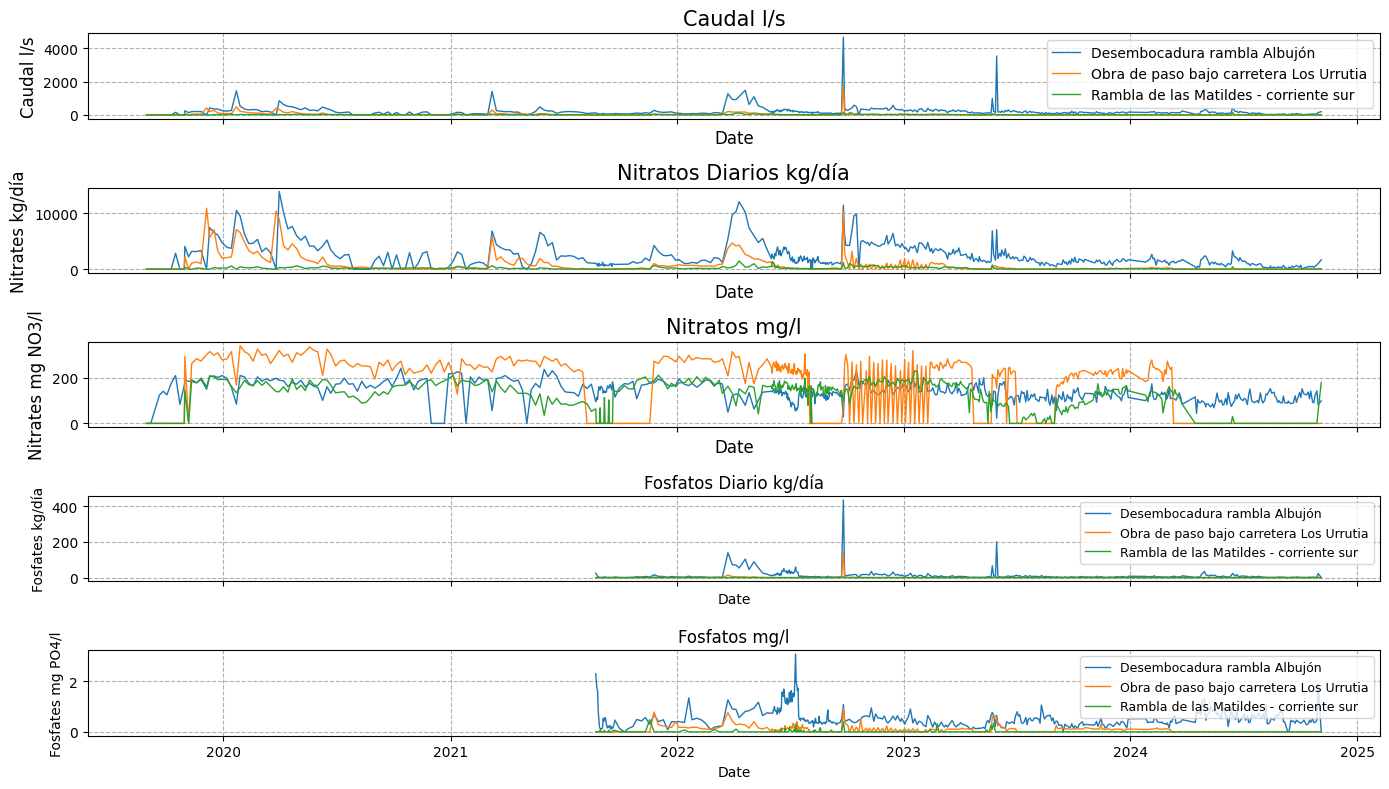

In [10]:
fig, ax = plt.subplots(figsize=(14, 8), nrows=5, ncols=1, sharex=True)

# Plots
# Caudal
for col in dataframes["Caudal"].columns[1:]:
    ax[0].plot(dataframes["Caudal"]["Fecha"], dataframes["Caudal"][col], label=f"{col}", linewidth=1.0)
ax[0].legend(loc="upper right", fontsize=10)
ax[0].set_ylabel("Caudal l/s", fontsize=12)
ax[0].set_xlabel("Date", fontsize=12)
ax[0].grid(linestyle='--')
ax[0].set_title("Caudal l/s", fontsize=15)

# Nitratos Diario
for col in dataframes["Nitratos Diario"].columns[1:]:
    ax[1].plot(dataframes["Nitratos Diario"]["Fecha"], dataframes["Nitratos Diario"][col], label=f"{col}", linewidth=1.0)
#ax[1].legend(loc="upper right", fontsize=9)
ax[1].set_ylabel("Nitrates kg/día", fontsize=12)
ax[1].set_xlabel("Date", fontsize=12)
ax[1].grid(linestyle='--')
ax[1].set_title("Nitratos Diarios kg/día", fontsize=15)

# Nitratos
for col in dataframes["Nitratos"].columns[1:]:
    ax[2].plot(dataframes["Nitratos"]["Fecha"], dataframes["Nitratos"][col], label=f"{col}", linewidth=1.0)
#ax[2].legend(loc="upper right", fontsize=9)
ax[2].set_ylabel("Nitrates mg NO3/l", fontsize=12)
ax[2].set_xlabel("Date", fontsize=12)
ax[2].grid(linestyle='--')
ax[2].set_title("Nitratos mg/l", fontsize=15)

# Fosfatos
for col in dataframes["Fosfatos Diario"].columns[1:]:
    ax[3].plot(dataframes["Fosfatos Diario"]["Fecha"], dataframes["Fosfatos Diario"][col], label=f"{col}", linewidth=1.0)
ax[3].legend(loc="upper right", fontsize=9)
ax[3].set_ylabel("Fosfates kg/día")
ax[3].set_xlabel("Date")
ax[3].grid(linestyle='--')
ax[3].set_title("Fosfatos Diario kg/día")

# # Fosfatos
for col in dataframes["Fosfatos"].columns[1:]:
    ax[4].plot(dataframes["Fosfatos"]["Fecha"], dataframes["Fosfatos"][col], label=f"{col}", linewidth=1.0)
ax[4].legend(loc="upper right", fontsize=9)
ax[4].set_ylabel("Fosfates mg PO4/l")
ax[4].set_xlabel("Date")
ax[4].grid(linestyle='--')
ax[4].set_title("Fosfatos mg/l")


fig.tight_layout()
#plt.savefig("saved_files/CanalMarMenor.svg")
plt.show()